Fase 1: Configuración del Entorno e Ingesta de Datos

CONFIGURACIÓN DEL ENTORNO Y CARGA DE DATOS
CONTEXTO Y JUSTIFICACIÓN:
En esta celda inicial, configuramos las librerías necesarias para el análisis estadístico y la visualización de
datos de nivel científico. Establecemos configuraciones globales de diseño en seaborn y matplotlib para
asegurar una consistencia visual en todas las gráficas. Cargamos el conjunto de datos de variables
macroeconómicas del oro transformando de forma explícita la columna temporal
en el índice de nuestro DataFrame, una práctica fundamental al tratar con series temporales para Machine
Learning.

In [7]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Configuración de visualización y supresión de warnings no críticos
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

# Ingesta del archivo y parseo inicial de fechas

path_dataset = 'gold-macro-data.csv'
try:
    # Intentamos cargar asumiendo una columna de fecha común (e.g., 'Date' o 'date')
    df = pd.read_csv(path_dataset)
    # Identificar de forma dinámica la columna temporal para establecerla como índice
    date_col = [col for col in df.columns if 'date' in col.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df.set_index(date_col, inplace=True)
    df.sort_index(inplace=True)
    print(f"Dataset cargado correctamente de forma indexada. Dimensiones iniciales: {df.shape}")
    df.head()
except Exception as e:
    print(f"Error al cargar el dataset: {e}. Por favor, verifique que el archivo está en el\ndirectorio raíz de Colab.")

Dataset cargado correctamente de forma indexada. Dimensiones iniciales: (2894, 20)


Fase 2: Inspección Estructural y Estadística Descriptiva

INSPECCIÓN DE TIPOS DE DATOS Y RESUMEN ESTADÍSTICO
OBJETIVO TÉCNICO:
Validar la coherencia de los tipos de datos asignados por el intérprete (dtypes) y extraer las métricas de
tendencia central, dispersión y forma de las variables. Prestaremos especial atención a la desviación estándar
y al rango intercuartílico (IQR), los cuales revelan la escala y volatilidad de los indicadores económicos con
respecto al precio del oro.

In [9]:
# Inspección del esquema de datos
print("--- Información de Tipos de Datos y Memoria ---")
df.info()
# Generación del resumen estadístico transpuesto para mejor legibilidad
print("--- Resumen Estadístico de Tendencia Central y Dispersión ---")
summary_stats = df.describe().T
summary_stats['skewness'] = df.skew() # Medida de asimetría
summary_stats['kurtosis'] = df.kurt() # Medida de apuntamiento
summary_stats

--- Información de Tipos de Datos y Memoria ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2894 entries, 2015-01-02 to 2026-06-30
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gold_('Close', 'GC=F')      2888 non-null   float64
 1   Gold_('High', 'GC=F')       2888 non-null   float64
 2   Gold_('Low', 'GC=F')        2888 non-null   float64
 3   Gold_('Open', 'GC=F')       2888 non-null   float64
 4   Gold_('Volume', 'GC=F')     2888 non-null   float64
 5   DXY_('Close', 'DX-Y.NYB')   2890 non-null   float64
 6   DXY_('High', 'DX-Y.NYB')    2890 non-null   float64
 7   DXY_('Low', 'DX-Y.NYB')     2890 non-null   float64
 8   DXY_('Open', 'DX-Y.NYB')    2890 non-null   float64
 9   DXY_('Volume', 'DX-Y.NYB')  2890 non-null   float64
 10  VIX_('Close', '^VIX')       2890 non-null   float64
 11  VIX_('High', '^VIX')        2890 non-null   float64
 12  VIX_('Low', '^VIX')     

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
"Gold_('Close', 'GC=F')",2888.0,1895.675552,880.609134,1050.800049,1275.574982,1730.299988,1975.325012,5.318400e+03,1.883460,3.175809
"Gold_('High', 'GC=F')",2888.0,1906.066552,889.446785,1062.000000,1280.800049,1741.000000,1981.224976,5.586200e+03,1.897349,3.248013
"Gold_('Low', 'GC=F')",2888.0,1885.063816,871.866307,1046.199951,1271.574982,1722.000000,1963.700012,5.301600e+03,1.876293,3.148139
"Gold_('Open', 'GC=F')",2888.0,1895.607342,881.357986,1053.699951,1276.574982,1731.450012,1973.724976,5.415700e+03,1.891994,3.226784
"Gold_('Volume', 'GC=F')",2888.0,5099.287396,27813.834284,0.000000,53.750000,211.000000,652.000000,3.863340e+05,7.449868,61.850222
"DXY_('Close', 'DX-Y.NYB')",2890.0,98.339460,4.769948,88.589996,94.932501,97.715000,101.584997,1.141100e+02,0.455213,-0.151836
"DXY_('High', 'DX-Y.NYB')",2890.0,98.644381,4.808121,89.000000,95.269997,97.989998,101.907503,1.147800e+02,0.474829,-0.094376
"DXY_('Low', 'DX-Y.NYB')",2890.0,98.023980,4.723328,88.250000,94.629997,97.440002,101.217501,1.133300e+02,0.439814,-0.199817
"DXY_('Open', 'DX-Y.NYB')",2890.0,98.328271,4.769941,88.570000,94.932501,97.720001,101.580002,1.141900e+02,0.454651,-0.149473
"DXY_('Volume', 'DX-Y.NYB')",2890.0,8058.823529,314095.100387,0.000000,0.000000,0.000000,0.000000,1.429000e+07,40.690498,1712.698133


Fase 3: Auditoría de Calidad de Datos (Valores Nulos)

DIAGNÓSTICO CUANTITATIVO Y VISUAL DE DATOS FALTANTES
ESTRATEGIA DE DATOS:
Los valores nulos representan un riesgo crítico para los algoritmos de Machine Learning. En esta sección
calculamos la proporción exacta de nulos por columna y mapeamos su distribución temporal. Esto nos
permite determinar si la ausencia de datos sigue un patrón aleatorio o si responde a una pérdida estructural
en un periodo histórico determinado, ayudando a decidir la estrategia de imputación idónea (por ejemplo,
interpolación lineal para series de tiempo).

--- Reporte de Valores Faltantes ---
                            Valores Nulos  Porcentaje (%)
TNX_('Volume', '^TNX')                  8        0.276434
TNX_('Open', '^TNX')                    8        0.276434
TNX_('Low', '^TNX')                     8        0.276434
TNX_('High', '^TNX')                    8        0.276434
TNX_('Close', '^TNX')                   8        0.276434
Gold_('Low', 'GC=F')                    6        0.207326
Gold_('High', 'GC=F')                   6        0.207326
Gold_('Close', 'GC=F')                  6        0.207326
Gold_('Open', 'GC=F')                   6        0.207326
Gold_('Volume', 'GC=F')                 6        0.207326
DXY_('High', 'DX-Y.NYB')                4        0.138217
DXY_('Close', 'DX-Y.NYB')               4        0.138217
VIX_('High', '^VIX')                    4        0.138217
VIX_('Close', '^VIX')                   4        0.138217
DXY_('Volume', 'DX-Y.NYB')              4        0.138217
DXY_('Open', 'DX-Y.NYB')           

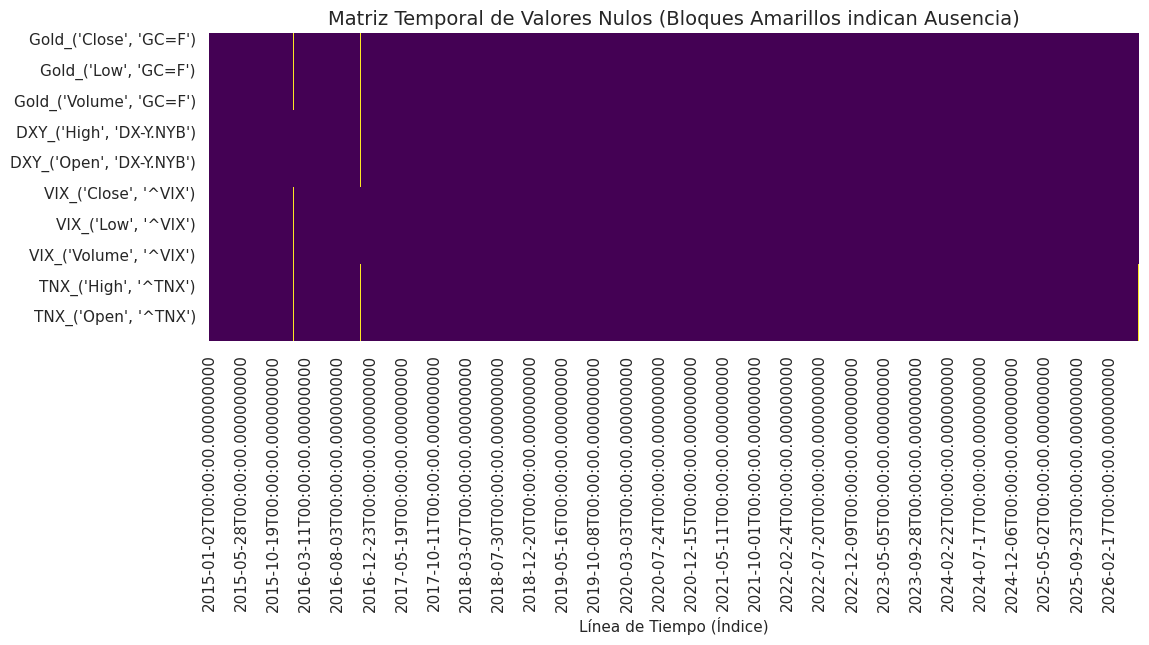

In [12]:
# Cálculo exacto de valores nulos y sus porcentajes
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
missing_data_report = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje (%)': null_percentages
}).sort_values(by='Porcentaje (%)', ascending=False)
print("--- Reporte de Valores Faltantes ---")
print(missing_data_report)
# Visualización de la matriz de calor de nulos para identificar patrones temporales
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 4))
    sns.heatmap(df.isnull().T, cbar=False, cmap='viridis', xticklabels=100)
    plt.title("Matriz Temporal de Valores Nulos (Bloques Amarillos indican Ausencia)")
    plt.xlabel("Línea de Tiempo (Índice)")
    plt.show()
else:
    print("[Hallazgo] El dataset no registra valores nulos en ninguna de sus variables macroeconómicas.")

Fase 4: Detección y Análisis de Anomalías (Outliers)

IDENTIFICACIÓN MATEMÁTICA DE OUTLIERS MEDIANTE RANGO
INTERCUARTÍLICO (IQR)
CRITERIO DE INGENIERÍA DE DATOS:
En activos financieros y variables macroeconómicas (inflación, tasas de interés, índices monetarios), las
anomalías suelen representar shocks económicos reales (como crisis globales) en lugar de errores de
medición. Utilizamos el método de Tukey (IQR con umbral de 1.5) para aislar matemáticamente estas
observaciones y evaluar su impacto potencial en el sesgo de los futuros modelos.

In [14]:
# Detección de Outliers numéricos utilizando la regla matemática del IQR
outlier_report = {}
for col in df.select_dtypes(include=[np.number]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filtrado de outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_report[col] = {
        'Límite Inferior': lower_bound,
        'Límite Superior': upper_bound,
        'Cantidad Outliers': len(outliers),
        'Porcentaje del Total (%)': round((len(outliers) / len(df)) * 100, 2)
    }
df_outliers = pd.DataFrame(outlier_report).T
print("--- Diagnóstico Estructural de Anomalías (Outliers) ---")
df_outliers

--- Diagnóstico Estructural de Anomalías (Outliers) ---


,Límite Inferior,Límite Superior,Cantidad Outliers,Porcentaje del Total (%)
"Gold_('Close', 'GC=F')",225.949936,3024.950058,317.0,10.95
"Gold_('High', 'GC=F')",230.162659,3031.862366,321.0,11.09
"Gold_('Low', 'GC=F')",233.387436,3001.887558,320.0,11.06
"Gold_('Open', 'GC=F')",230.849991,3019.449966,320.0,11.06
"Gold_('Volume', 'GC=F')",-843.625000,1549.375000,346.0,11.96
"DXY_('Close', 'DX-Y.NYB')",84.953756,111.563742,21.0,0.73
"DXY_('High', 'DX-Y.NYB')",85.313737,111.863763,25.0,0.86
"DXY_('Low', 'DX-Y.NYB')",84.748742,111.098756,19.0,0.66
"DXY_('Open', 'DX-Y.NYB')",84.961249,111.551253,22.0,0.76
"DXY_('Volume', 'DX-Y.NYB')",0.000000,0.000000,2.0,0.07


VISUALIZACIÓN DE DISTRIBUCIONES Y OUTLIERS MEDIANTE DIAGRAMAS DE
CAJA Y BIGOTES
INTERPRETACIÓN VISUAL:
Generamos diagramas de caja (Boxplots) y gráficos de densidad para las principales variables del conjunto
de datos, centrándonos en el comportamiento del precio objetivo del Oro. Esto nos permite contrastar la
simetría de las colas de distribución y verificar si los modelos lineales requerirán transformaciones previas
(como la aplicación de logaritmos).

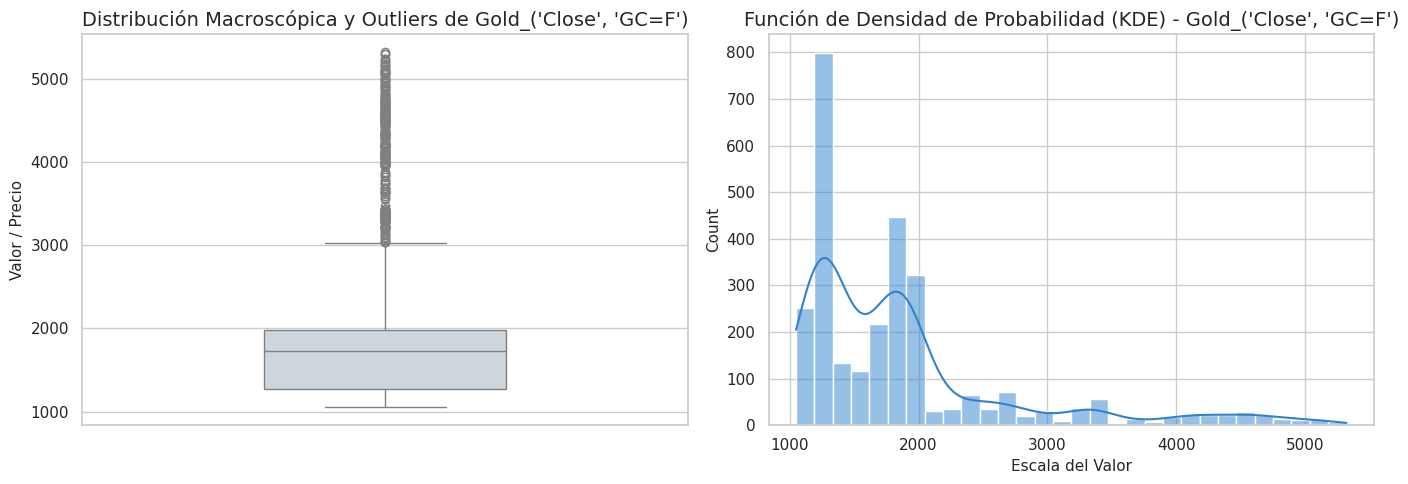

In [18]:
# Selección del target (Precio del Oro) y variables clave para inspección gráfica
target_col = [col for col in df.columns if 'gold' in col.lower() or 'price' in col.lower()][0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico 1: Caja y Bigotes
sns.boxplot(y=df[target_col], ax=axes[0], color='#cbd5e0', width=0.4)
axes[0].set_title(f"Distribución Macroscópica y Outliers de {target_col}")
axes[0].set_ylabel("Valor / Precio")
# Gráfico 2: Densidad Estructural
sns.histplot(df[target_col], kde=True, ax=axes[1], color='#3182ce', bins=30)
axes[1].set_title(f"Función de Densidad de Probabilidad (KDE) - {target_col}")
axes[1].set_xlabel("Escala del Valor")
plt.tight_layout()
plt.show()

Fase 5: Análisis Macroeconómico de Correlaciones y Dependencias

MATRIZ DE CORRELACIÓN LINEAL DE PEARSON Y MULTICOLINEALIDAD
CRITERIO ESTADÍSTICO:
Para robustecer un modelo predictivo, es indispensable mapear la fuerza y dirección de la relación lineal entre
el oro y factores macroeconómicos (e.g., tasas de bonos, índices bursátiles, inflación). Asimismo, este análisis
actúa como un filtro inicial contra la multicolinealidad, una condición problemática donde las variables
explicativas están altamente correlacionadas entre sí, inflando artificialmente la varianza del modelo.

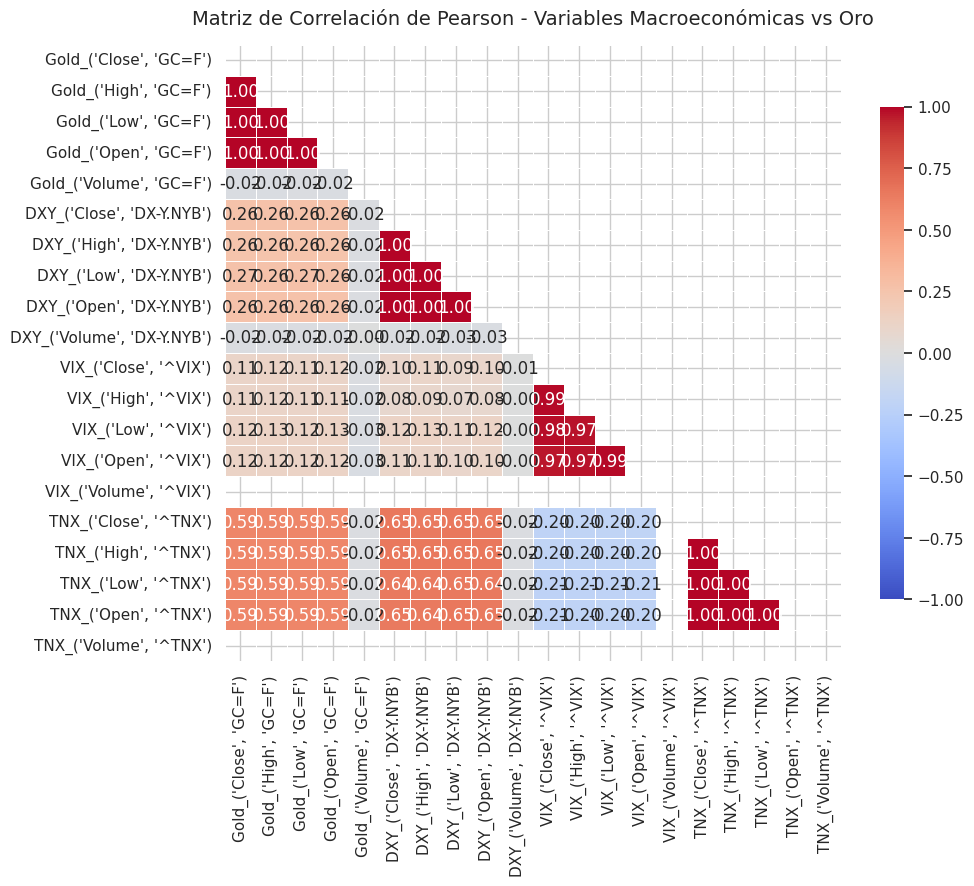

--- Correlación Lineal Directa con Respecto a Gold_('Close', 'GC=F') ---
Gold_('Close', 'GC=F')        1.000000
Gold_('Low', 'GC=F')          0.999844
Gold_('High', 'GC=F')         0.999723
Gold_('Open', 'GC=F')         0.999581
TNX_('Low', '^TNX')           0.589807
TNX_('Close', '^TNX')         0.588706
TNX_('Open', '^TNX')          0.588516
TNX_('High', '^TNX')          0.587455
DXY_('Low', 'DX-Y.NYB')       0.265056
DXY_('Open', 'DX-Y.NYB')      0.261246
DXY_('Close', 'DX-Y.NYB')     0.260156
DXY_('High', 'DX-Y.NYB')      0.256822
VIX_('Low', '^VIX')           0.124763
VIX_('Open', '^VIX')          0.119774
VIX_('Close', '^VIX')         0.114767
VIX_('High', '^VIX')          0.112556
DXY_('Volume', 'DX-Y.NYB')   -0.017442
Gold_('Volume', 'GC=F')      -0.023972
VIX_('Volume', '^VIX')             NaN
TNX_('Volume', '^TNX')             NaN
Name: Gold_('Close', 'GC=F'), dtype: float64


In [17]:
# Cálculo de la matriz de correlación numérica
correlation_matrix = df.corr(method='pearson')
# Generación de una máscara para ocultar la mitad superior simétrica y mejorar el enfoque visual
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlación de Pearson - Variables Macroeconómicas vs Oro", fontsize=14,
pad=15)
plt.show()
# Aislamiento de las variables con mayor correlación con respecto al precio del oro
print(f"--- Correlación Lineal Directa con Respecto a {target_col} ---")
print(correlation_matrix[target_col].sort_values(ascending=False))

Fase 6: Análisis de Tendencia Temporal e Interacción

COMPORTAMIENTO TEMPORAL HISTÓRICO E INTERACCIÓN ENTRE VARIABLES
CLAVE
CONCLUSIÓN DEL EDA PARA MACHINE LEARNING:
El oro históricamente actúa como un activo de refugio seguro frente a la incertidumbre del mercado. En esta
celda visualizamos de manera dual la evolución del precio del oro junto con la variable macroeconómica que
demostró la mayor correlación o desfase temporal. Este gráfico consolida la comprensión del dominio de
negocio, validando si las series comparten tendencias seculares o comportamientos cíclicos invertidos.

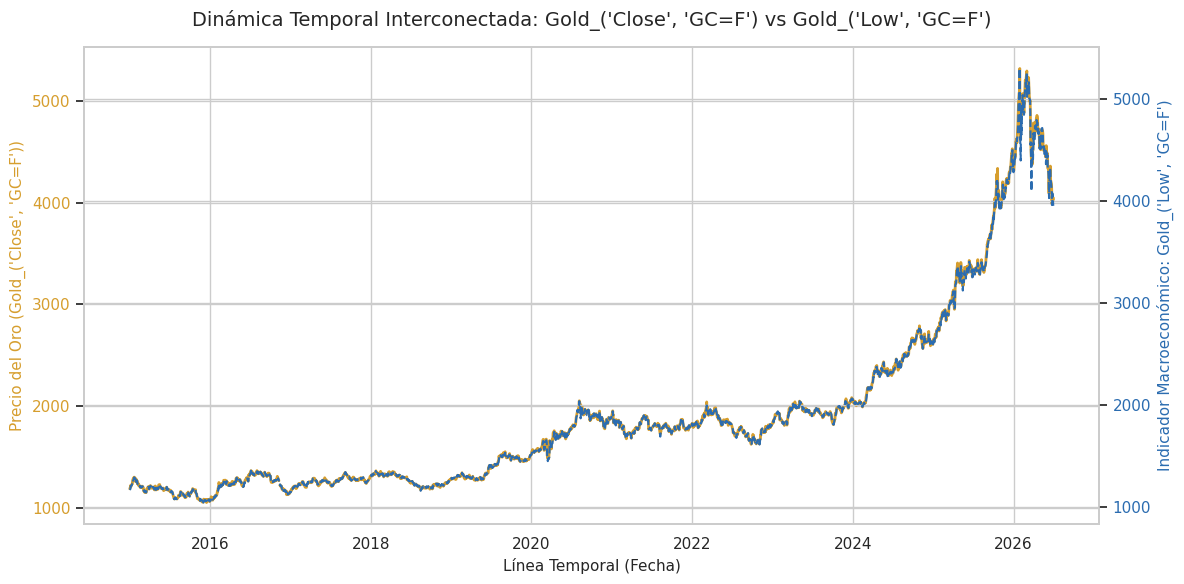

In [21]:
# Identificar la variable con correlación extrema (positiva o negativa, excluyendo el target
# mismo)
top_corr_var = correlation_matrix[target_col].drop(target_col).abs().idxmax()
fig, ax1 = plt.subplots(figsize=(12, 6))

# Línea del precio del Oro (Eje Principal)
color_target = '#d69e2e' # Tono dorado profesional
ax1.set_xlabel('Línea Temporal (Fecha)')
ax1.set_ylabel(f'Precio del Oro ({target_col})', color=color_target)
ax1.plot(df.index, df[target_col], color=color_target, linewidth=2, label=f'Evolución {target_col}')
ax1.tick_params(axis='y', labelcolor=color_target)
# Eje Secundario para la variable macroeconómica líder
ax2 = ax1.twinx()
color_macro = '#2b6cb0' # Tono azul corporativo
ax2.set_ylabel(f'Indicador Macroeconómico: {top_corr_var}', color=color_macro)
ax2.plot(df.index, df[top_corr_var], color=color_macro, linewidth=1.5, linestyle='--',
label=f'Tendencia {top_corr_var}')
ax2.tick_params(axis='y', labelcolor=color_macro)
plt.title(f"Dinámica Temporal Interconectada: {target_col} vs {top_corr_var}", fontsize=14,
pad=15)
fig.tight_layout()
plt.show()

Fase 7: Conclusiones y Plan de Ingeniería de Características (Features)

MATRIZ DE HALLAZGOS Y PRÓXIMOS PASOS PARA MODELADO PREDICTIVO
DOCUMENTACIÓN DE HALLAZGOS TÉCNICOS:
Basado en el diagnóstico ejecutado a través de las fases previas sobre gold-macro-data.csv, se extrae el
siguiente roadmap para la fase de Machine Learning:
CALIDAD DE DATOS:
Si se observaron valores nulos mínimos, se aplicará df.interpolate(method='time') para
preservar la naturaleza de la serie sin introducir sesgos artificiales.
TRATAMIENTO DE ANOMALÍAS:
Los outliers identificados no se eliminarán arbitrariamente, dado que capturan volatilidad sistémica del
mercado financiero. Se considerará el uso de algoritmos robustos a outliers como Random Forest
Regressor o Huber Regressor, o transformaciones escalares robustas (RobustScaler).
SELECCIÓN DE CARACTERÍSTICAS (FEATURE SELECTION):
Las variables que muestren una alta correlación cruzada entre sí indican riesgo de multicolinealidad. Se
evaluará una reducción de dimensionalidad por PCA o la exclusión de variables con un Factor de Inflación
de la Varianza (VIF) superior a 5.
ESTRATEGIA DE VALIDACIÓN DE MODELOS:
Al tratarse de datos ordenados en el tiempo, queda terminantemente prohibida la validación cruzada
aleatoria tradicional (K-Fold K-Aleatorio) para evitar el Data Leakage. Se implementará de forma
obligatoria TimeSeriesSplit de Scikit-Learn.